In [2]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

import torch
from transformers import AutoTokenizer, pipeline, AutoModelForSequenceClassification, TrainingArguments, Trainer,  DataCollatorWithPadding

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


c:\Users\s7omb\AppData\Local\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("emotion")

Sanity check

In [3]:
ds.shape

{'train': (16000, 2), 'validation': (2000, 2), 'test': (2000, 2)}

In [4]:
ds["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [5]:
ds["train"].to_pandas().head(5)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


Кросс валидация данных (встроенная)

In [6]:
train_data = ds["train"]
train_data

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [7]:
val_data = ds["validation"]

In [8]:
test_data = ds["test"]

In [3]:
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Классификация происходит на основе тональности текстов (0-5). Где  

   0 - sadness    (грусть, печаль)
   
   1 - joy        (радость, счастье)

   2 - love       (любовь, нежность)

   3 - anger      (гнев, злость)

   4 - fear       (страх, тревога)
   
   5 - surprise   (удивление)

In [11]:
classes = ["sadness", "joy", "love", "anger", "fear", "surprise"]

In [12]:
example_text =train_data["text"][5:10]
example_label = train_data["label"][5:10]

In [13]:
def detailed_token_analys(text, tokenizer):

    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens = False)

    tokens_with_special = tokenizer.tokenize(text)
    tokens_special = tokenizer.encode(tokens, add_special_tokens = True, return_attention_mask = True, return_token_type_ids = True)

    return {
        "tokens": tokens,
        "token_ids": token_ids,
        "tokens_with_special": tokens_with_special,
        "tokens_ids_special":  tokens_special
    }

In [14]:
def show_padding_truncation(text, tokenizer,  max_length = 15):
    
    encoded_simple = tokenizer(text, add_special_tokens = True, padding = False, truncation = False)

    encoded_padding = tokenizer(text, add_special_tokens = True, padding = True, truncation = False)

    encoded_truncation = tokenizer(text, add_special_tokens = True, padding = False, truncation = True,   max_length=  max_length)

    encoded_both = tokenizer(text, add_special_tokens=True, padding=True, truncation=True,  max_length= max_length)

    return encoded_simple, encoded_padding, encoded_truncation , encoded_both

In [15]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5254.99it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. 

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [16]:
text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer
)

In [17]:
display(detailed_token_analys(example_text, tokenizer))

{'tokens': ['i',
  '##ve',
  'been',
  'feeling',
  'a',
  'little',
  'bu',
  '##rden',
  '##ed',
  'late',
  '##ly',
  'wasn',
  '##t',
  'sure',
  'why',
  'that',
  'was'],
 'token_ids': [[177,
   10612,
   10590,
   61362,
   169,
   16745,
   11499,
   26505,
   10336,
   13002,
   10454,
   65390,
   10123,
   62452,
   31237,
   10189,
   10134],
  [177,
   10612,
   10590,
   18084,
   10345,
   34795,
   31253,
   10107,
   10345,
   13465,
   48864,
   24074,
   10111,
   177,
   10612,
   40055,
   24491,
   91633,
   169,
   19826,
   66109,
   10473,
   177,
   10379,
   38008,
   11850,
   10380,
   41807,
   10756],
  [177,
   38008,
   10146,
   73173,
   10978,
   12103,
   10146,
   169,
   33003,
   37247,
   10345,
   10146,
   10201,
   21597,
   10146,
   169,
   10924,
   12898,
   10817],
  [177,
   10529,
   10590,
   10169,
   32784,
   35997,
   10107,
   10142,
   10855,
   177,
   38008,
   10189,
   32784,
   35997,
   10107,
   10393,
   15282,
   11206,

In [18]:
display(show_padding_truncation(example_text, tokenizer))

({'input_ids': [[101, 177, 10612, 10590, 61362, 169, 16745, 11499, 26505, 10336, 13002, 10454, 65390, 10123, 62452, 31237, 10189, 10134, 102], [101, 177, 10612, 10590, 18084, 10345, 34795, 31253, 10107, 10345, 13465, 48864, 24074, 10111, 177, 10612, 40055, 24491, 91633, 169, 19826, 66109, 10473, 177, 10379, 38008, 11850, 10380, 41807, 10756, 102], [101, 177, 38008, 10146, 73173, 10978, 12103, 10146, 169, 33003, 37247, 10345, 10146, 10201, 21597, 10146, 169, 10924, 12898, 10817, 102], [101, 177, 10529, 10590, 10169, 32784, 35997, 10107, 10142, 10855, 177, 38008, 10189, 32784, 35997, 10107, 10393, 15282, 11206, 10111, 11019, 169, 42126, 25081, 102], [101, 177, 38008, 57349, 16683, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [19]:
inputs = tokenizer(
    example_text, 
    padding=True,
    truncation=True, 
    max_length=128,
    return_tensors="pt"
)
inputs = {key: value.to(device) for key, value in inputs.items()}

In [20]:
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)
    predictions = torch.argmax(logits, dim=1)

# 7. Обработка результатов
predictions_cpu = predictions.cpu().tolist()
probabilities_cpu = probabilities.cpu().numpy()

In [21]:
for i, (text, true_label, pred_label) in enumerate(zip(example_text, example_label, predictions_cpu)):
    true_emotion = classes[true_label]
    pred_emotion = classes[pred_label]
    confidence = probabilities_cpu[i][pred_label]

    print(f"\nТекст: {text}")
    print(f"   Истинная: {true_emotion} → Предсказанная: {pred_emotion} (уверенность {confidence:.1%})")


Текст: ive been feeling a little burdened lately wasnt sure why that was
   Истинная: sadness → Предсказанная: joy (уверенность 55.9%)

Текст: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
   Истинная: surprise → Предсказанная: joy (уверенность 56.1%)

Текст: i feel as confused about life as a teenager or as jaded as a year old man
   Истинная: fear → Предсказанная: joy (уверенность 50.5%)

Текст: i have been with petronas for years i feel that petronas has performed well and made a huge profit
   Истинная: joy → Предсказанная: sadness (уверенность 57.6%)

Текст: i feel romantic too
   Истинная: love → Предсказанная: joy (уверенность 54.9%)


Анализ модели:

Модель выбирает тональность наугад, а значит она не подходит для решения этой задачи без дообучения.

In [22]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels = 6).to(device)
model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3080.91it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. 

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [23]:
def tokenize(examples):
    return tokenizer(
        examples["text"],
        padding = "max_length",
        truncation = True,
        return_tensors = None,
        max_length = 32
    )

In [24]:
tokenized_dataset = ds.map(tokenize, batched = True)

In [25]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

In [26]:
tokenized_train = tokenized_dataset["train"]
tokenized_val = tokenized_dataset["validation"]
tokenized_test = tokenized_dataset["test"]

In [ ]:
labels = tokenized_train["label"]

labels_list = list(labels)
pd.Series(labels_list).value_counts(normalize=True)

1    0.337333
0    0.289111
3    0.135222
4    0.117000
2    0.082333
5    0.039000
Name: proportion, dtype: float64

In [27]:
tokenized_train.to_pandas().head(5)

,label,input_ids,token_type_ids,attention_mask
0,0,"[101, 177, 34420, 10123, 38008, 26506, 55177, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, ..."
1,0,"[101, 177, 10944, 11783, 10188, 61362, 10380, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,3,"[101, 10211, 63706, 37801, 10376, 169, 21760, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,2,"[101, 177, 10392, 17038, 61362, 11573, 14191, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,3,"[101, 177, 10392, 61362, 30518, 11010, 27199, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ..."


In [28]:
example = tokenized_train[0]
print("Ключи примера:", example.keys())
print("labels:", example["label"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [101, 177, 34420, 10123, 38008, 26506, 55177, 89771, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [29]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = 1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average = "macro")
    f1_weighted = f1_score(labels, preds, average = "weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

In [31]:
tokenized_train = tokenized_train.select(range(9000))
tokenized_val= tokenized_val.select(range(1000))
tokenized_test= tokenized_test.select(range(1000))

In [32]:
# Общие параметры обучения
common_training_kwargs = dict(
    output_dir="./emotion_results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    learning_rate=1e-5,
    weight_decay=0.01,
    fp16=True,
)

training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    **common_training_kwargs,
        )


In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    )

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.972064,0.902789,0.673000,0.398209,0.606135


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=563, training_loss=1.2199980293666914, metrics={'train_runtime': 1250.5852, 'train_samples_per_second': 7.197, 'train_steps_per_second': 0.45, 'total_flos': 148005283968000.0, 'train_loss': 1.2199980293666914, 'epoch': 1.0})

In [48]:
trainer.callback_handler.callbacks = []

val_results = trainer.evaluate(tokenized_val)

test_results = trainer.evaluate(tokenized_test)
test_results

{'eval_loss': 0.8956801295280457,
 'eval_accuracy': 0.679,
 'eval_f1_macro': 0.411464699007216,
 'eval_f1_weighted': 0.6156502575466861,
 'eval_runtime': 19.1781,
 'eval_samples_per_second': 52.143,
 'eval_steps_per_second': 0.834,
 'epoch': 1.0}

In [36]:
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids
test_output

PredictionOutput(predictions=array([[ 1.1842268 ,  2.1404433 ,  0.04666236, -0.5159794 , -0.47705317,
        -1.1579201 ],
       [ 2.3933203 , -0.65277994, -1.452276  ,  0.44417614,  0.5091032 ,
        -0.74959624],
       [ 2.565962  , -0.40868837, -1.1873357 , -0.08296521,  0.25797898,
        -1.1262395 ],
       ...,
       [-0.6872584 ,  2.6416306 ,  1.3147871 , -0.9264568 , -1.2011652 ,
        -0.871737  ],
       [-0.5786593 ,  2.7732415 ,  1.272565  , -0.92336684, -1.181574  ,
        -0.8064681 ],
       [ 2.4453664 , -0.94874203, -1.5918212 ,  0.29474357,  0.6629119 ,
        -0.90064394]], dtype=float32), label_ids=array([0, 0, 0, 1, 0, 4, 3, 1, 1, 3, 4, 0, 4, 1, 2, 0, 1, 0, 3, 1, 0, 1,
       1, 0, 0, 4, 3, 0, 4, 3, 4, 3, 0, 3, 0, 1, 1, 0, 1, 1, 3, 0, 1, 0,
       1, 3, 1, 1, 4, 4, 0, 4, 1, 0, 1, 0, 0, 1, 0, 3, 0, 0, 1, 1, 0, 5,
       0, 3, 4, 5, 1, 2, 5, 1, 2, 3, 1, 0, 1, 2, 1, 3, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 4, 3, 4, 3, 3, 2, 0, 3, 0, 0, 0, 0, 4, 3, 3, 1, 1, 4, 

In [37]:

def samples_prediction( trainer, n_samples = 20):

    samples_pred = []

    id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"} 

    for i in range(n_samples):
        text = tokenizer.decode(tokenized_test[i]["input_ids"])
        test_true = tokenized_test["label"][i]
        true_label = id2label[test_true]

        pred = trainer.predict(tokenized_test.select([i]))
        test_logits = pred.predictions
        conf = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
        test_preds = np.argmax(test_logits, axis=-1)
        pred_label = id2label[test_preds[0]]

        samples_pred.append({
            "text": text,
            "true_label": true_label,
            "pred_label": pred_label,
            "confidence": conf[0, test_preds[0]]
        })

    return pd.DataFrame(samples_pred)


samples_prediction(trainer).to_csv("artifacts/sample_predictions.csv")

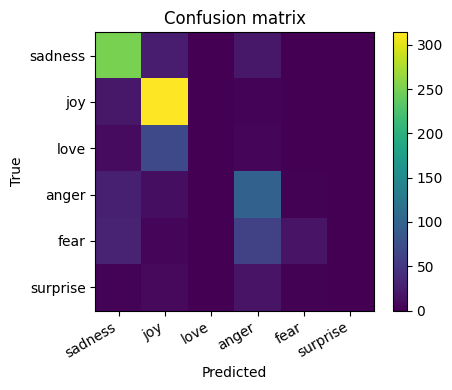

In [38]:
cm = confusion_matrix(test_true, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

In [50]:
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            confusions.append((i, j, cm[i, j]))

# Сортируем по количеству ошибок
confusions.sort(key=lambda x: x[2], reverse=True)
print("Топ-5 самых частых ошибок:")
for i, (true_class, pred_class, count) in enumerate(confusions[:5]):
        print(f"{i+1}. Класс {true_class} → предсказан как {pred_class}: {count} раз")

Топ-5 самых частых ошибок:
1. Класс 2 → предсказан как 1: 69 раз
2. Класс 4 → предсказан как 3: 62 раз
3. Класс 4 → предсказан как 0: 31 раз
4. Класс 3 → предсказан как 0: 28 раз
5. Класс 0 → предсказан как 1: 24 раз
